SUBJECT: MACHINE LEARNING PROJECTS WITH PYTHON (CSE 4192)

ASSIGNMENT_(2): New York Taxi Fare Prediction Using  Deep Feedforward Neural Networks

Team Members:

NAME: UMANG KUMAR CHOURASIA ___REG_NO: 2341003058

NAME: ADITYA KUMAR SAHAY___REG_NO: 2341019019

NAME: KHUSHI SINGH___REG_NO: 2341019515

NAME: DIKSHA RAJ___REG_NO: 2341018024

SECTION: 23412D2

In [1]:
# 1. SETUP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
sns.set_style('whitegrid')
print(tf.__version__, tf.config.list_physical_devices('GPU'))

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# 2. LOAD & UNDERSTAND DATA
from google.colab import drive
drive.mount('/content/drive')
N_ROWS = 500_000
df = pd.read_csv('/content/drive/MyDrive/train.csv', nrows=N_ROWS)
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])

print('Shape:', df.shape)
print('\nFirst records:'); print(df.head())
print('\nLast records:'); print(df.tail())
print('\nData types:'); print(df.dtypes)
print('\nDescriptive statistics:'); print(df.describe().T)

TARGET = 'fare_amount'
print('\nTarget variable:', TARGET)
print('Fare range: $%.2f to $%.2f' % (df[TARGET].min(), df[TARGET].max()))
print('\nPassenger count distribution:'); print(df['passenger_count'].value_counts().sort_index())
print('\nPickup coordinate range: lat [%.2f, %.2f], lon [%.2f, %.2f]' %
      (df.pickup_latitude.min(), df.pickup_latitude.max(), df.pickup_longitude.min(), df.pickup_longitude.max()))
print('Pickup datetime range:', df.pickup_datetime.min(), 'to', df.pickup_datetime.max())

# Dataset summary table (expected output)
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(3),
    'n_unique': df.nunique(),
})
print('\nDataset summary table:'); print(summary)

Mounted at /content/drive
Shape: (500000, 8)

First records:
                             key  fare_amount          pickup_datetime  \
0    2009-06-15 17:26:21.0000001          4.5  2009-06-15 17:26:21 UTC   
1    2010-01-05 16:52:16.0000002         16.9  2010-01-05 16:52:16 UTC   
2   2011-08-18 00:35:00.00000049          5.7  2011-08-18 00:35:00 UTC   
3    2012-04-21 04:30:42.0000001          7.7  2012-04-21 04:30:42 UTC   
4  2010-03-09 07:51:00.000000135          5.3  2010-03-09 07:51:00 UTC   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.844311        40.721319         -73.841610         40.712278   
1        -74.016048        40.711303         -73.979268         40.782004   
2        -73.982738        40.761270         -73.991242         40.750562   
3        -73.987130        40.733143         -73.991567         40.758092   
4        -73.968095        40.768008         -73.956655         40.783762   

   passenger_count  
0         

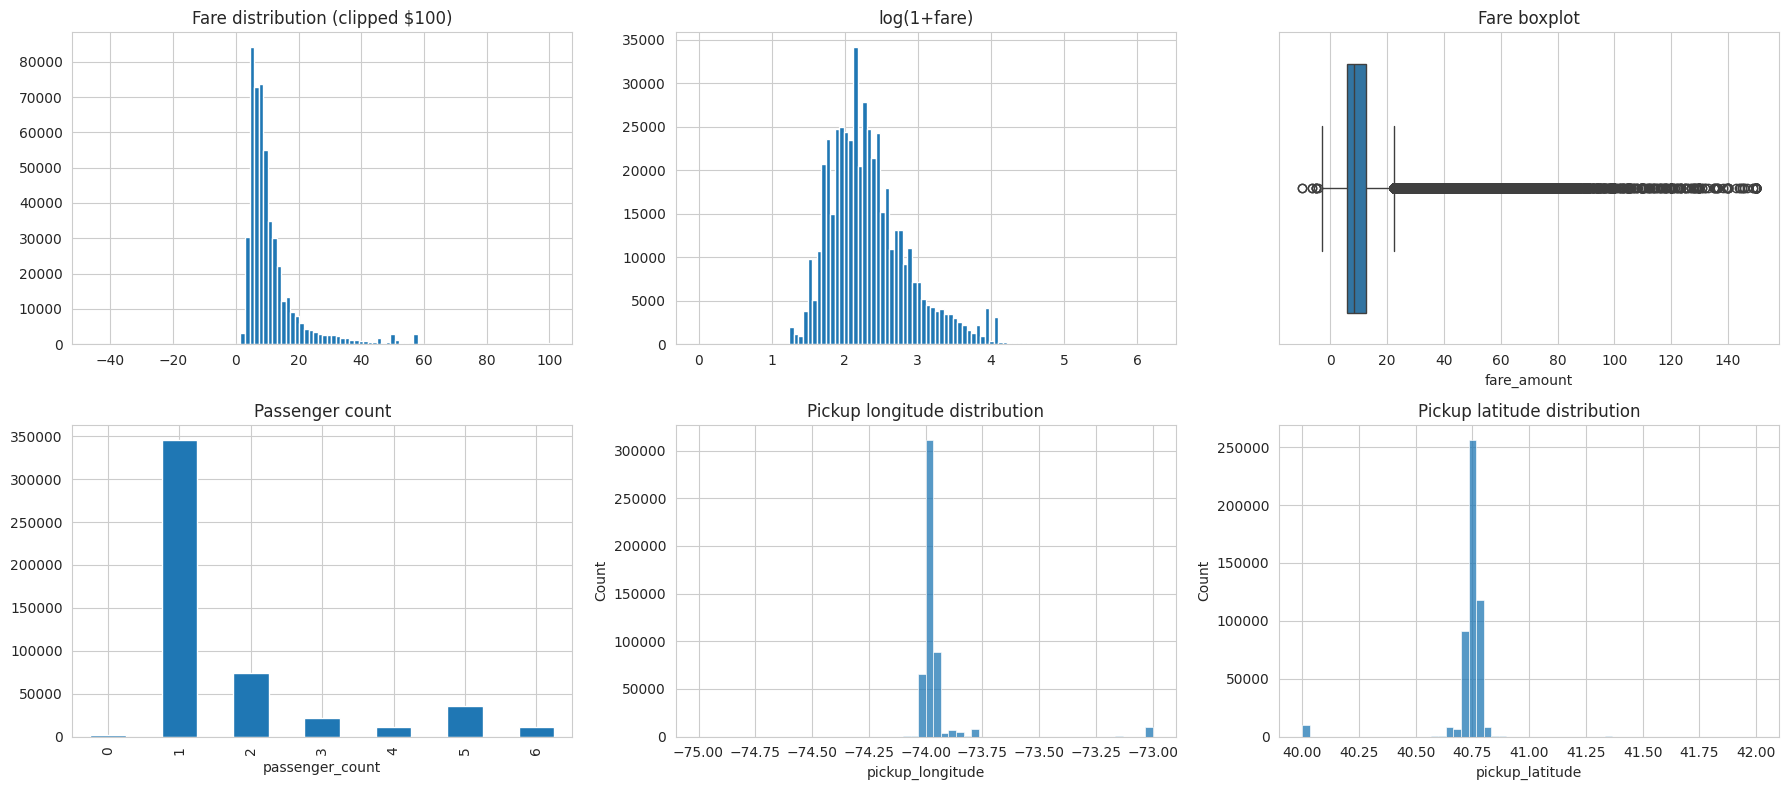

Fare skewness: 4.9
Fares <= 0: 35 (0.007%)


In [4]:
# 3. EDA — UNIVARIATE & TARGET ANALYSIS
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes[0,0].hist(df[TARGET].clip(upper=100), bins=100); axes[0,0].set_title('Fare distribution (clipped $100)')
axes[0,1].hist(np.log1p(df[TARGET].clip(lower=0)), bins=100); axes[0,1].set_title('log(1+fare)')
sns.boxplot(x=df[TARGET].clip(-10, 150), ax=axes[0,2]); axes[0,2].set_title('Fare boxplot')
df['passenger_count'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0]); axes[1,0].set_title('Passenger count')
sns.histplot(df.pickup_longitude.clip(-75, -73), bins=60, ax=axes[1,1]); axes[1,1].set_title('Pickup longitude distribution')
sns.histplot(df.pickup_latitude.clip(40, 42), bins=60, ax=axes[1,2]); axes[1,2].set_title('Pickup latitude distribution')
plt.tight_layout(); plt.show()

print('Fare skewness:', round(df[TARGET].skew(), 2))
n_diabetic = (df[TARGET] <= 0).sum()
print(f'Fares <= 0: {n_diabetic} ({n_diabetic/len(df)*100:.3f}%)')

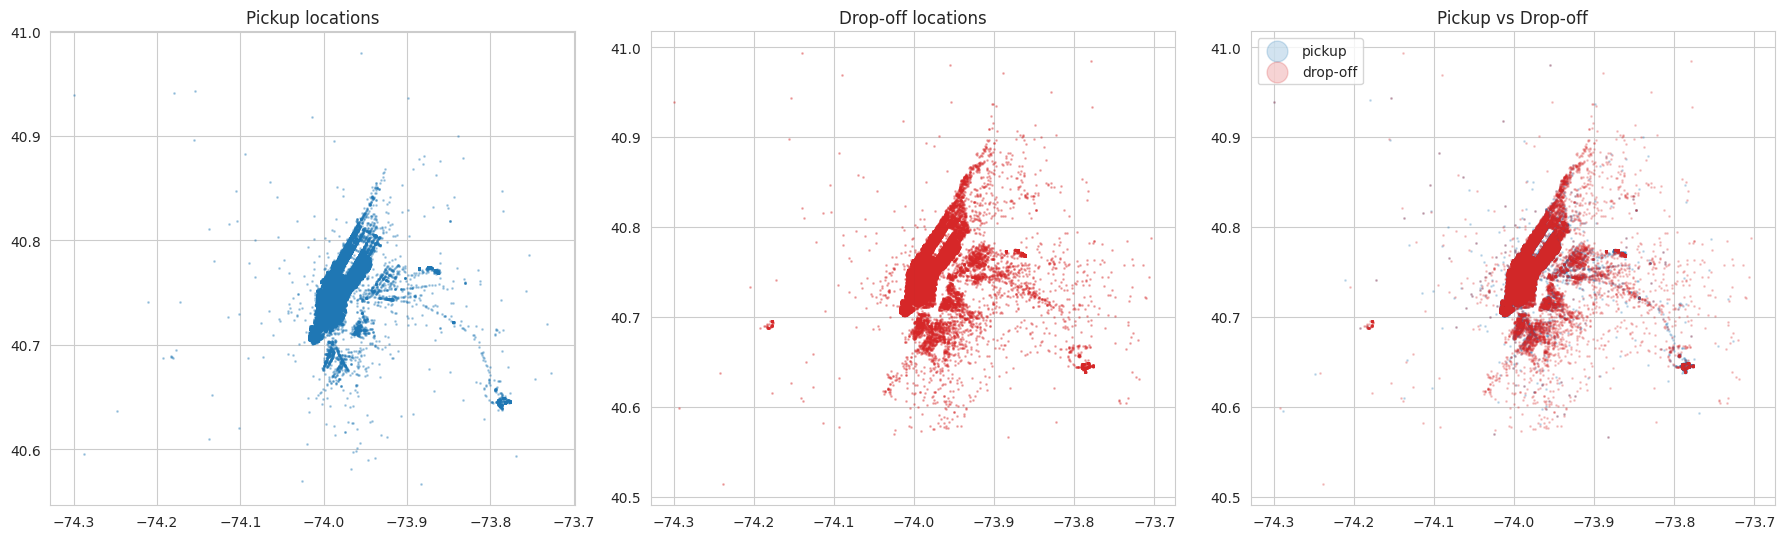

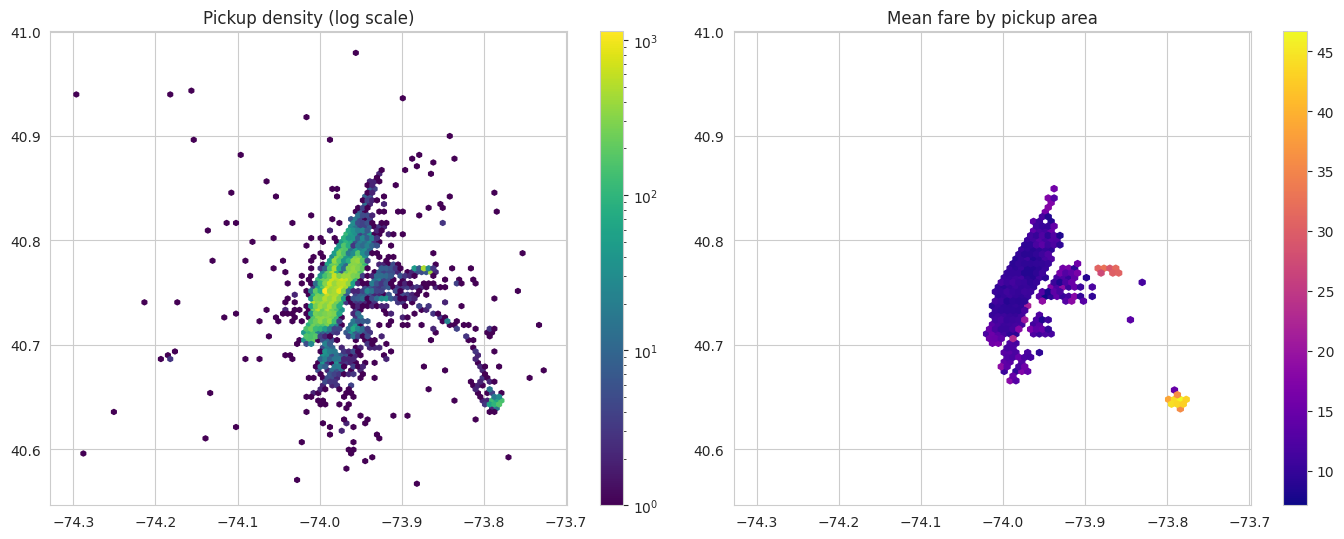

Pickups outside NYC box: 10293
Coordinates at exactly (0,0): 9401
-> These are data anomalies (GPS errors / logging failures), not real NYC trips.


In [5]:
# 4. VISUALIZING GEOLOCATION DATA
NYC = dict(lat_min=40.5, lat_max=41.0, lon_min=-74.3, lon_max=-73.7)
def in_box(lat, lon):
    return lat.between(NYC['lat_min'], NYC['lat_max']) & lon.between(NYC['lon_min'], NYC['lon_max'])

s = df.dropna().sample(min(50_000, len(df)), random_state=RANDOM_SEED)
sv = s[in_box(s.pickup_latitude, s.pickup_longitude) & in_box(s.dropoff_latitude, s.dropoff_longitude)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
axes[0].scatter(sv.pickup_longitude, sv.pickup_latitude, s=1, alpha=0.3, c='tab:blue')
axes[0].set_title('Pickup locations')
axes[1].scatter(sv.dropoff_longitude, sv.dropoff_latitude, s=1, alpha=0.3, c='tab:red')
axes[1].set_title('Drop-off locations')
axes[2].scatter(sv.pickup_longitude, sv.pickup_latitude, s=1, alpha=0.2, c='tab:blue', label='pickup')
axes[2].scatter(sv.dropoff_longitude, sv.dropoff_latitude, s=1, alpha=0.2, c='tab:red', label='drop-off')
axes[2].legend(markerscale=15); axes[2].set_title('Pickup vs Drop-off')
plt.tight_layout(); plt.show()

# density + fare-by-area
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
h1 = axes[0].hexbin(sv.pickup_longitude, sv.pickup_latitude, gridsize=100, bins='log', cmap='viridis')
axes[0].set_title('Pickup density (log scale)'); plt.colorbar(h1, ax=axes[0])
h2 = axes[1].hexbin(sv.pickup_longitude, sv.pickup_latitude, C=sv[TARGET].clip(upper=80),
                     reduce_C_function=np.mean, gridsize=80, cmap='plasma', mincnt=5)
axes[1].set_title('Mean fare by pickup area'); plt.colorbar(h2, ax=axes[1])
plt.tight_layout(); plt.show()

# investigate unusual coordinates
d = df.dropna()
print('Pickups outside NYC box:', (~in_box(d.pickup_latitude, d.pickup_longitude)).sum())
print('Coordinates at exactly (0,0):', ((d.pickup_latitude == 0) & (d.pickup_longitude == 0)).sum())
print('-> These are data anomalies (GPS errors / logging failures), not real NYC trips.')

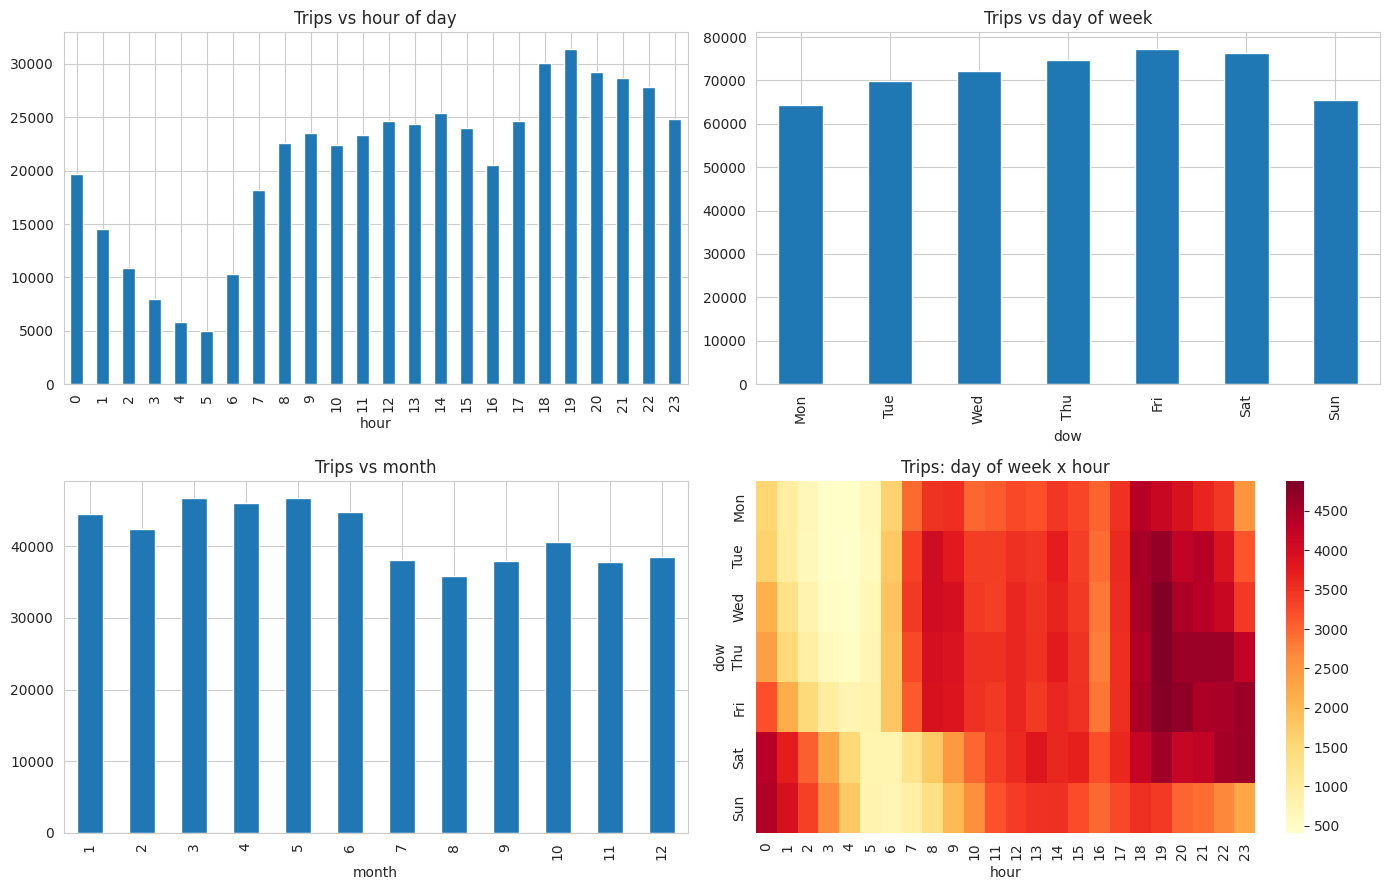

Peak hour: 19:00 | Lowest-demand hour: 5:00
Avg weekday trips/hour: 14933 | Avg weekend trips/hour: 5900
Mean fare by hour (first/last 3):
hour
0     11.77
1     11.44
2     11.51
3     12.08
4     13.69
5     15.17
6     12.31
7     10.95
8     10.91
9     10.82
10    10.90
11    11.19
12    11.13
13    11.65
14    11.87
15    12.09
16    11.84
17    11.38
18    10.98
19    10.60
20    10.83
21    11.00
22    11.32
23    11.56
Name: fare_amount, dtype: float64


In [6]:
# 5. RIDERSHIP BY DAY AND HOUR
t = df.dropna(subset=['pickup_datetime']).copy()
t['pickup_datetime'] = pd.to_datetime(t['pickup_datetime'], errors='coerce')
t = t.dropna(subset=['pickup_datetime'])
t['hour'] = t.pickup_datetime.dt.hour
t['dow'] = t.pickup_datetime.dt.dayofweek
t['month'] = t.pickup_datetime.dt.month
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
t.groupby('hour').size().plot(kind='bar', ax=axes[0,0], title='Trips vs hour of day')
t.groupby('dow').size().rename(dict(enumerate(days))).plot(kind='bar', ax=axes[0,1], title='Trips vs day of week')
t.groupby('month').size().plot(kind='bar', ax=axes[1,0], title='Trips vs month')
heat = t.pivot_table(index='dow', columns='hour', values=TARGET, aggfunc='size').rename(index=dict(enumerate(days)))
sns.heatmap(heat, cmap='YlOrRd', ax=axes[1,1]); axes[1,1].set_title('Trips: day of week x hour')
plt.tight_layout(); plt.show()

peak_hour = t.groupby('hour').size().idxmax()
low_hour = t.groupby('hour').size().idxmin()
weekday_avg = t[t.dow < 5].groupby('hour').size().mean()
weekend_avg = t[t.dow >= 5].groupby('hour').size().mean()
print(f'Peak hour: {peak_hour}:00 | Lowest-demand hour: {low_hour}:00')
print(f'Avg weekday trips/hour: {weekday_avg:.0f} | Avg weekend trips/hour: {weekend_avg:.0f}')
print('Mean fare by hour (first/last 3):'); print(t.groupby('hour')[TARGET].mean().round(2))

In [7]:
# 6. DATA PREPROCESSING — MISSING VALUES & ANOMALIES
print('Missing values per column:'); print(df.isna().sum())
print('Missing %:'); print((df.isna().mean() * 100).round(3))
print('-> Coordinates/time cannot be meaningfully imputed, so rows with missing values are dropped.')

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

d = df.dropna().copy()
d['dist_km'] = haversine(d.pickup_latitude, d.pickup_longitude, d.dropoff_latitude, d.dropoff_longitude)

anomalies = {
    'Negative fare': (d[TARGET] < 0).sum(),
    'Zero fare': (d[TARGET] == 0).sum(),
    'Fare < $2.50 (below NYC minimum)': ((d[TARGET] > 0) & (d[TARGET] < 2.5)).sum(),
    'Fare > $200 (implausibly high)': (d[TARGET] > 200).sum(),
    'Passenger count == 0': (d.passenger_count == 0).sum(),
    'Passenger count > 6': (d.passenger_count > 6).sum(),
    'Invalid latitude (|lat|>90)': ((d.pickup_latitude.abs() > 90) | (d.dropoff_latitude.abs() > 90)).sum(),
    'Invalid longitude (|lon|>180)': ((d.pickup_longitude.abs() > 180) | (d.dropoff_longitude.abs() > 180)).sum(),
    'Outside NYC region': (~in_box(d.pickup_latitude, d.pickup_longitude) | ~in_box(d.dropoff_latitude, d.dropoff_longitude)).sum(),
    'Distance < 0.05 km (GPS glitch)': (d.dist_km < 0.05).sum(),
    'Distance > 100 km (implausible)': (d.dist_km > 100).sum(),
    'Duplicate rows': d.duplicated().sum(),
}
print('\nAnomaly counts (before removal):')
print(pd.Series(anomalies, name='count').to_frame().assign(pct=lambda x: (x['count']/len(d)*100).round(4)))

# apply cleaning, each with a justification
clean = df.copy()
before = len(clean)
clean = clean.dropna()
clean['dist_km'] = haversine(clean.pickup_latitude, clean.pickup_longitude, clean.dropoff_latitude, clean.dropoff_longitude)
clean = clean.drop_duplicates()
clean = clean[clean[TARGET].between(2.5, 200)]          # below legal minimum / implausibly high -> likely errors
clean = clean[clean.passenger_count.between(1, 6)]       # 0 = no fare-paying rider, >6 exceeds legal capacity
clean = clean[in_box(clean.pickup_latitude, clean.pickup_longitude)]
clean = clean[in_box(clean.dropoff_latitude, clean.dropoff_longitude)]
clean = clean[clean.dist_km.between(0.05, 100)]          # near-zero = GPS failure, >100km = not a real NYC taxi trip

print(f'\nRows before cleaning: {before} | after cleaning: {len(clean)} ({len(clean)/before*100:.1f}% kept)')
print('Note: long/expensive trips under $200 (e.g. airport runs) were deliberately KEPT, not treated as errors.')

Missing values per column:
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
dtype: int64
Missing %:
key                  0.000
fare_amount          0.000
pickup_datetime      0.000
pickup_longitude     0.000
pickup_latitude      0.000
dropoff_longitude    0.001
dropoff_latitude     0.001
passenger_count      0.000
dtype: float64
-> Coordinates/time cannot be meaningfully imputed, so rows with missing values are dropped.

Anomaly counts (before removal):
                                  count     pct
Negative fare                        21  0.0042
Zero fare                            14  0.0028
Fare < $2.50 (below NYC minimum)      6  0.0012
Fare > $200 (implausibly high)       26  0.0052
Passenger count == 0               1791  0.3582
Passenger count > 6                   0  0.0000
Invalid latitude (|lat|>90)           9  0.0018
Invalid longitude (|lon

In [8]:
# 7. FEATURE ENGINEERING
clean['pickup_datetime'] = pd.to_datetime(clean['pickup_datetime'], errors='coerce')
clean = clean.dropna(subset=['pickup_datetime'])

clean['hour'] = clean.pickup_datetime.dt.hour
clean['day'] = clean.pickup_datetime.dt.day
clean['dayofweek'] = clean.pickup_datetime.dt.dayofweek
clean['month'] = clean.pickup_datetime.dt.month
clean['year'] = clean.pickup_datetime.dt.year
clean['is_weekend'] = (clean.dayofweek >= 5).astype(int)
clean['dlat'] = clean.dropoff_latitude - clean.pickup_latitude          # coordinate difference feature
clean['dlon'] = clean.dropoff_longitude - clean.pickup_longitude
clean['dist_per_passenger'] = clean.dist_km / clean.passenger_count      # optional extra feature

FEATURES = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
            'passenger_count', 'dist_km', 'dlat', 'dlon', 'dist_per_passenger',
            'hour', 'day', 'dayofweek', 'month', 'year', 'is_weekend']

X = clean[FEATURES]
y = clean[TARGET]
print(X.shape)
print(X.head())
print('''
Rationale:
- dist_km: fare is dominated by distance travelled.
- dlat/dlon: raw direction of travel, cheap extra signal alongside dist_km.
- dist_per_passenger: tests whether shared cost per rider matters.
- hour/dayofweek/month/year/is_weekend: fares vary with traffic, demand, and fare-rate changes over time.
''')

(480010, 15)
   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.844311        40.721319         -73.841610         40.712278   
1        -74.016048        40.711303         -73.979268         40.782004   
2        -73.982738        40.761270         -73.991242         40.750562   
3        -73.987130        40.733143         -73.991567         40.758092   
4        -73.968095        40.768008         -73.956655         40.783762   

   passenger_count   dist_km      dlat      dlon  dist_per_passenger  hour  \
0                1  1.030764 -0.009041  0.002701            1.030764    17   
1                1  8.450134  0.070701  0.036780            8.450134    16   
2                2  1.389525 -0.010708 -0.008504            0.694763     0   
3                1  2.799270  0.024949 -0.004437            2.799270     4   
4                1  1.999157  0.015754  0.011440            1.999157     7   

   day  dayofweek  month  year  is_weekend  
0   15    

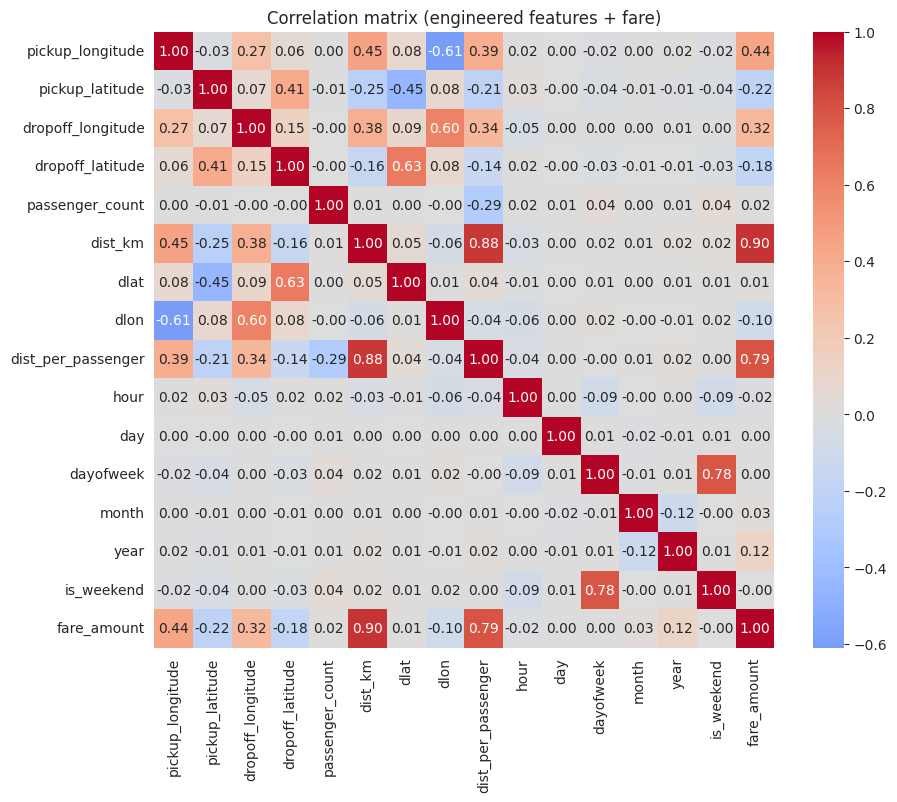

Correlation with fare (sorted):
dist_km               0.897857
dist_per_passenger    0.788323
pickup_longitude      0.436646
dropoff_longitude     0.324612
pickup_latitude      -0.219762
dropoff_latitude     -0.182718
year                  0.124341
dlon                 -0.095446
month                 0.026195
hour                 -0.019668
passenger_count       0.016721
dlat                  0.007883
dayofweek             0.003185
is_weekend           -0.002421
day                   0.001712
Name: fare_amount, dtype: float64


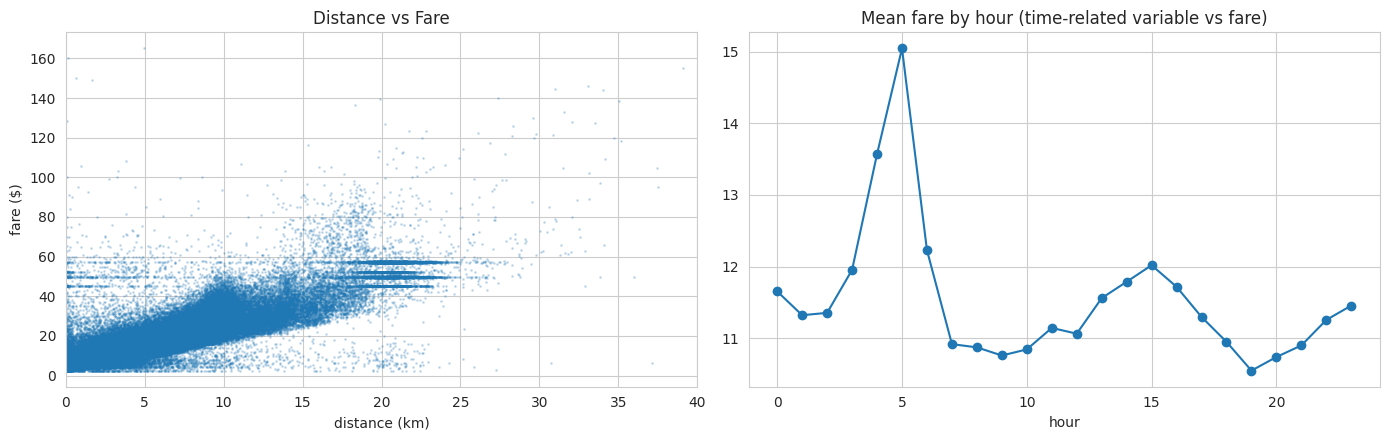

Potentially redundant feature pairs (|corr| > 0.9):
Empty DataFrame
Columns: [level_0, level_1, corr]
Index: []


In [9]:
# 8. FEATURE ANALYSIS
plt.figure(figsize=(10, 8))
sns.heatmap(X.assign(fare_amount=y).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (engineered features + fare)')
plt.show()

corr_with_fare = X.assign(fare_amount=y).corr()['fare_amount'].drop('fare_amount').sort_values(key=abs, ascending=False)
print('Correlation with fare (sorted):'); print(corr_with_fare)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].scatter(X.dist_km, y, s=1, alpha=0.2); axes[0].set_xlim(0, 40)
axes[0].set_xlabel('distance (km)'); axes[0].set_ylabel('fare ($)'); axes[0].set_title('Distance vs Fare')
X.assign(fare_amount=y).groupby('hour').fare_amount.mean().plot(ax=axes[1], marker='o')
axes[1].set_title('Mean fare by hour (time-related variable vs fare)')
plt.tight_layout(); plt.show()

# redundancy check
pairs = X.corr().where(np.triu(np.ones(X.corr().shape, bool), 1)).stack().rename('corr').reset_index()
red = pairs[pairs['corr'].abs() > 0.9]
print('Potentially redundant feature pairs (|corr| > 0.9):'); print(red)

train/val/test sizes: 384008 48001 48001


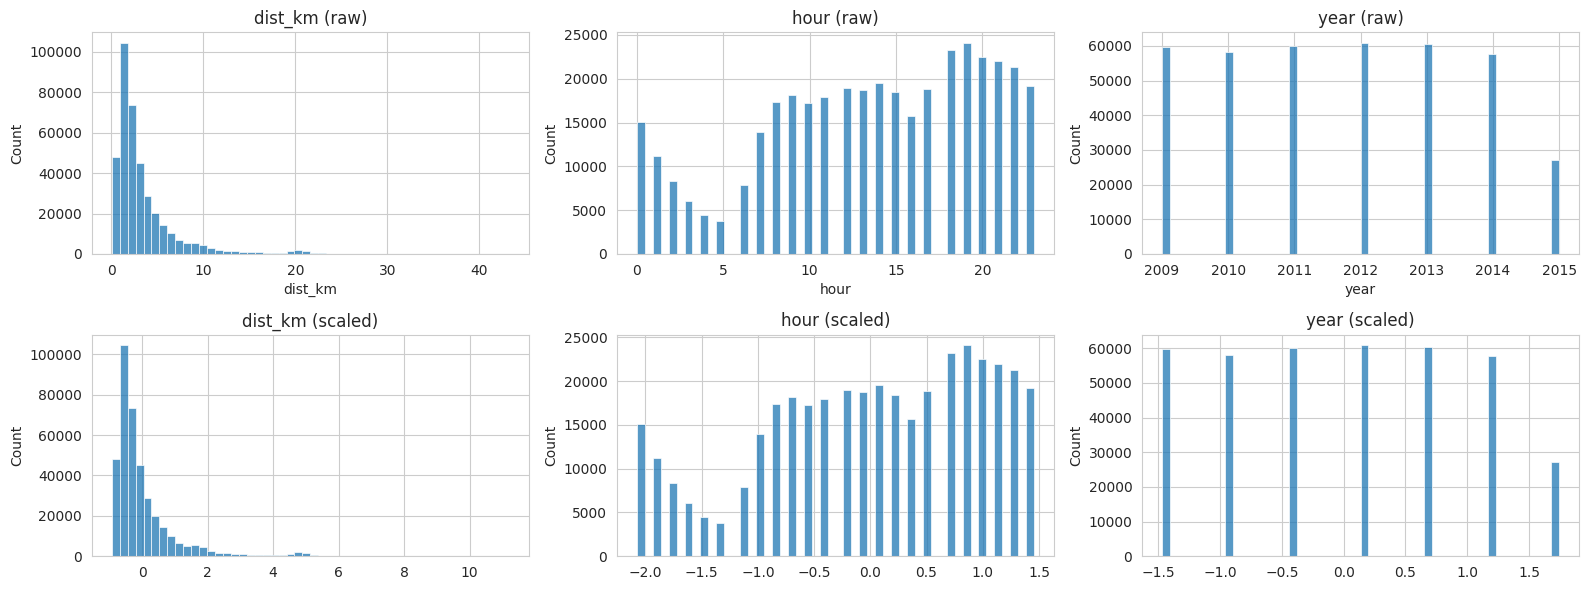

Scaled train mean (~0): [-0. -0.  0.] | std (~1): [1. 1. 1.]


In [10]:
# 9. TRAIN / VALIDATION / TEST SPLIT + SCALING
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=RANDOM_SEED)
print('train/val/test sizes:', X_train.shape[0], X_val.shape[0], X_test.shape[0])

# Why scaling matters: features are on very different scales (year ~2012, latitude ~40.7,
# hour 0-23, distance 0-50km). Unscaled inputs slow/destabilize gradient descent for a neural net.
scaler = StandardScaler().fit(X_train)          # fit on TRAINING data only -> no leakage
X_train_sc = scaler.transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# before vs after scaling comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
cols_to_show = ['dist_km', 'hour', 'year']
for i, c in enumerate(cols_to_show):
    sns.histplot(X_train[c], bins=50, ax=axes[0, i]); axes[0, i].set_title(f'{c} (raw)')
    sns.histplot(X_train_sc[:, FEATURES.index(c)], bins=50, ax=axes[1, i]); axes[1, i].set_title(f'{c} (scaled)')
plt.tight_layout(); plt.show()
print('Scaled train mean (~0):', np.round(X_train_sc.mean(0)[:3], 3), '| std (~1):', np.round(X_train_sc.std(0)[:3], 3))

In [11]:
# 10. BASELINE MODELS
def report(name, y_true, y_pred):
    return {'Model': name,
            'MAE': mean_absolute_error(y_true, y_pred),
            'MSE': mean_squared_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2': r2_score(y_true, y_pred)}

results = []
lin = LinearRegression().fit(X_train_sc, y_train)
results.append(report('Linear Regression', y_val, lin.predict(X_val_sc)))

rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(report('Random Forest', y_val, rf.predict(X_val)))

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,2.157745,16.340777,4.042373,0.813687
1,Random Forest,1.721332,11.073272,3.327653,0.873745


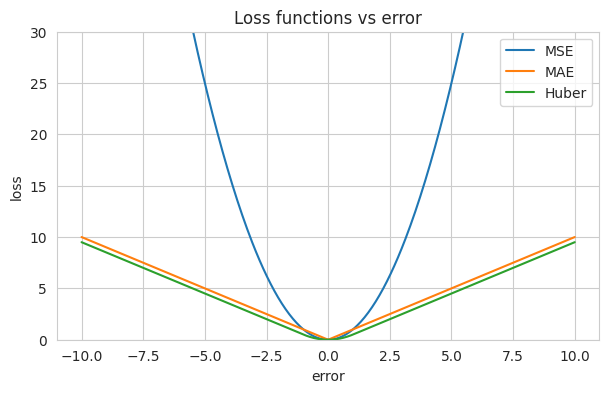

Taxi fares are right-skewed with noisy long trips even after cleaning -> Huber chosen: robust to outliers like MAE, smooth like MSE.


In [12]:
# 11. LOSS FUNCTIONS FOR REGRESSION
# MSE = mean((y - y_hat)^2)      -> penalizes large errors heavily, sensitive to outliers, optimizes the mean
# MAE = mean(|y - y_hat|)        -> linear penalty, robust to outliers, optimizes the median
# Huber = quadratic for small errors, linear for large errors -> smooth + robust compromise
e = np.linspace(-10, 10, 400)
delta = 1.0
mse_l = e**2
mae_l = np.abs(e)
huber_l = np.where(np.abs(e) <= delta, 0.5*e**2, delta*(np.abs(e) - 0.5*delta))

plt.figure(figsize=(7, 4))
plt.plot(e, mse_l, label='MSE'); plt.plot(e, mae_l, label='MAE'); plt.plot(e, huber_l, label='Huber')
plt.ylim(0, 30); plt.xlabel('error'); plt.ylabel('loss'); plt.legend(); plt.title('Loss functions vs error')
plt.show()
print('Taxi fares are right-skewed with noisy long trips even after cleaning -> Huber chosen: robust to outliers like MAE, smooth like MSE.')

In [13]:
# 12. DEEP FEEDFORWARD NEURAL NETWORK
# Architecture: 3 hidden layers (128-64-32) funnel shape, ReLU activations, dropout for regularization,
# linear output (fare is an unbounded continuous value, so no final activation).
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(X_train_sc.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='huber',
                  metrics=['mae', keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

model = build_model()
model.summary()

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)]
history = model.fit(X_train_sc, y_train, validation_data=(X_val_sc, y_val),
                     epochs=60, batch_size=256, callbacks=callbacks, verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 1.9325 - mae: 2.3610 - rmse: 4.4504 - val_loss: 1.3721 - val_mae: 1.7779 - val_rmse: 3.6824
Epoch 2/60
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.5014 - mae: 1.9159 - rmse: 3.6950 - val_loss: 1.2883 - val_mae: 1.6961 - val_rmse: 3.5283
Epoch 3/60
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.4217 - mae: 1.8319 - rmse: 3.5867 - val_loss: 1.2410 - val_mae: 1.6473 - val_rmse: 3.4574
Epoch 4/60
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.3781 - mae: 1.7856 - rmse: 3.5325 - val_loss: 1.2392 - val_mae: 1.6405 - val_rmse: 3.4894
Epoch 5/60
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.3539 - mae: 1.7599 - rmse: 3.5054 - val_loss: 1.2695 - val_mae: 1.6690 - val_rmse: 3.5606
Epoch 6/60
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.3385 - mae: 1.7437 - rmse: 3.4871 - val_loss: 1.2470 - val_mae: 1.6458 - val_rmse: 3.5138
Epoch 7/60
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.3241 - mae:

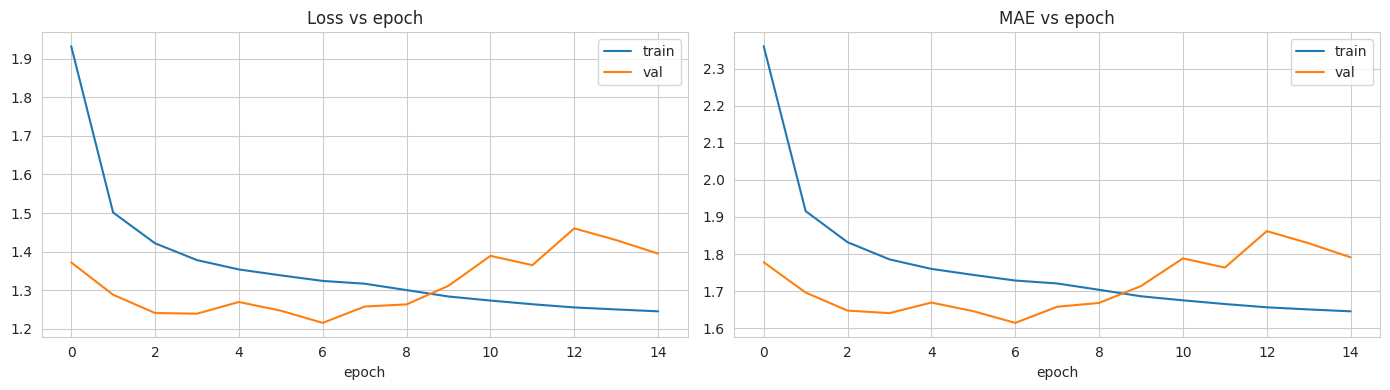

Best epoch (min val loss): 7 | train MAE 1.728 | val MAE 1.614 | gap -0.114
Small gap -> little overfitting. Large/growing gap -> overfitting (more dropout/less capacity needed).
Flat/high loss on both -> underfitting (need a bigger network or more informative features).
Early stopping triggered at epoch: 15 of 60 requested.


In [14]:
# 13. MODEL TRAINING ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss vs epoch'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history.history['mae'], label='train'); axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE vs epoch'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
train_mae_best = history.history['mae'][best_epoch-1]
val_mae_best = history.history['val_mae'][best_epoch-1]
gap = val_mae_best - train_mae_best
print(f'Best epoch (min val loss): {best_epoch} | train MAE {train_mae_best:.3f} | val MAE {val_mae_best:.3f} | gap {gap:.3f}')
print('Small gap -> little overfitting. Large/growing gap -> overfitting (more dropout/less capacity needed).')
print('Flat/high loss on both -> underfitting (need a bigger network or more informative features).')
print('Early stopping triggered at epoch:', len(history.history['loss']), 'of 60 requested.')

In [15]:
# 14. HYPERPARAMETER TUNING (manual grid over layers, neurons, lr, dropout, batch size, optimizer, loss)
grid = [
    {'units': (128, 64, 32), 'lr': 0.001,  'dropout': 0.2, 'batch_size': 256, 'optimizer': 'adam',    'loss': 'huber'},
    {'units': (64, 32),      'lr': 0.001,  'dropout': 0.3, 'batch_size': 256, 'optimizer': 'adam',    'loss': 'mae'},
    {'units': (128, 64, 32), 'lr': 0.0005, 'dropout': 0.3, 'batch_size': 128, 'optimizer': 'rmsprop', 'loss': 'huber'},
    {'units': (256, 128, 64),'lr': 0.001,  'dropout': 0.3, 'batch_size': 256, 'optimizer': 'adam',    'loss': 'mse'},
    {'units': (128, 64),     'lr': 0.01,   'dropout': 0.2, 'batch_size': 64,  'optimizer': 'sgd',     'loss': 'huber'},
]

def make_optimizer(name, lr):
    return {'adam': keras.optimizers.Adam(lr), 'rmsprop': keras.optimizers.RMSprop(lr),
            'sgd': keras.optimizers.SGD(lr, momentum=0.9)}[name]

def build_variant(units, lr, dropout, optimizer, loss):
    m = keras.Sequential([layers.Input(shape=(X_train_sc.shape[1],))])
    for u in units:
        m.add(layers.Dense(u, activation='relu')); m.add(layers.Dropout(dropout))
    m.add(layers.Dense(1))
    m.compile(optimizer=make_optimizer(optimizer, lr), loss=loss, metrics=['mae'])
    return m

tuning_results = []
for cfg in grid:
    keras.backend.clear_session()
    m = build_variant(cfg['units'], cfg['lr'], cfg['dropout'], cfg['optimizer'], cfg['loss'])
    h = m.fit(X_train_sc, y_train, validation_data=(X_val_sc, y_val), epochs=15,
              batch_size=cfg['batch_size'], verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(monitor='val_mae', patience=3, restore_best_weights=True)])
    tuning_results.append({**cfg, 'val_mae': min(h.history['val_mae'])})

tuning_df = pd.DataFrame(tuning_results).sort_values('val_mae').reset_index(drop=True)
tuning_df

,units,lr,dropout,batch_size,optimizer,loss,val_mae
0,"(128, 64, 32)",0.0005,0.3,128,rmsprop,huber,1.649485
1,"(128, 64)",0.0100,0.2,64,sgd,huber,1.662089
2,"(128, 64, 32)",0.0010,0.2,256,adam,huber,1.669547
3,"(256, 128, 64)",0.0010,0.3,256,adam,mse,1.722339
4,"(64, 32)",0.0010,0.3,256,adam,mae,1.783448


In [16]:
# 15. FINAL MODEL — retrain best configuration
best = tuning_df.iloc[0]
print('Best config:', dict(best))

keras.backend.clear_session()
final_model = build_variant(best['units'], best['lr'], best['dropout'], best['optimizer'], best['loss'])
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)]
final_history = final_model.fit(X_train_sc, y_train, validation_data=(X_val_sc, y_val),
                                epochs=80, batch_size=int(best['batch_size']), callbacks=callbacks, verbose=1)

Best config: {'units': (128, 64, 32), 'lr': np.float64(0.0005), 'dropout': np.float64(0.3), 'batch_size': np.int64(128), 'optimizer': 'rmsprop', 'loss': 'huber', 'val_mae': np.float64(1.6494845151901245)}
Epoch 1/80
3001/3001 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 2.3617 - mae: 2.8043 - val_loss: 1.5001 - val_mae: 1.9065
Epoch 2/80
3001/3001 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.8993 - mae: 2.3277 - val_loss: 1.3938 - val_mae: 1.7974
Epoch 3/80
3001/3001 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.7866 - mae: 2.2099 - val_loss: 1.3142 - val_mae: 1.7173
Epoch 4/80
3001/3001 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.7168 - mae: 2.1361 - val_loss: 1.3035 - val_mae: 1.7082
Epoch 5/80
3001/3001 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.6598 - mae: 2.0769 - val_loss: 1.2987 - val_mae: 1.7040
Epoch 6/80
3001/3001 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.6207 - mae: 2.0361 - val_loss: 1.2756 - val_mae: 1.6790
Epoch 7/80
3001/3001 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.5968 - mae

1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
{'Model': 'Final Tuned DNN', 'MAE': 1.640539624790398, 'MSE': 12.731506359759704, 'RMSE': np.float64(3.5681236469270097), 'R2': 0.8564990647377418}
               Model       MAE        MSE      RMSE        R2
0  Linear Regression  2.157745  16.340777  4.042373  0.813687
1      Random Forest  1.721332  11.073272  3.327653  0.873745
2    Final Tuned DNN  1.640540  12.731506  3.568124  0.856499


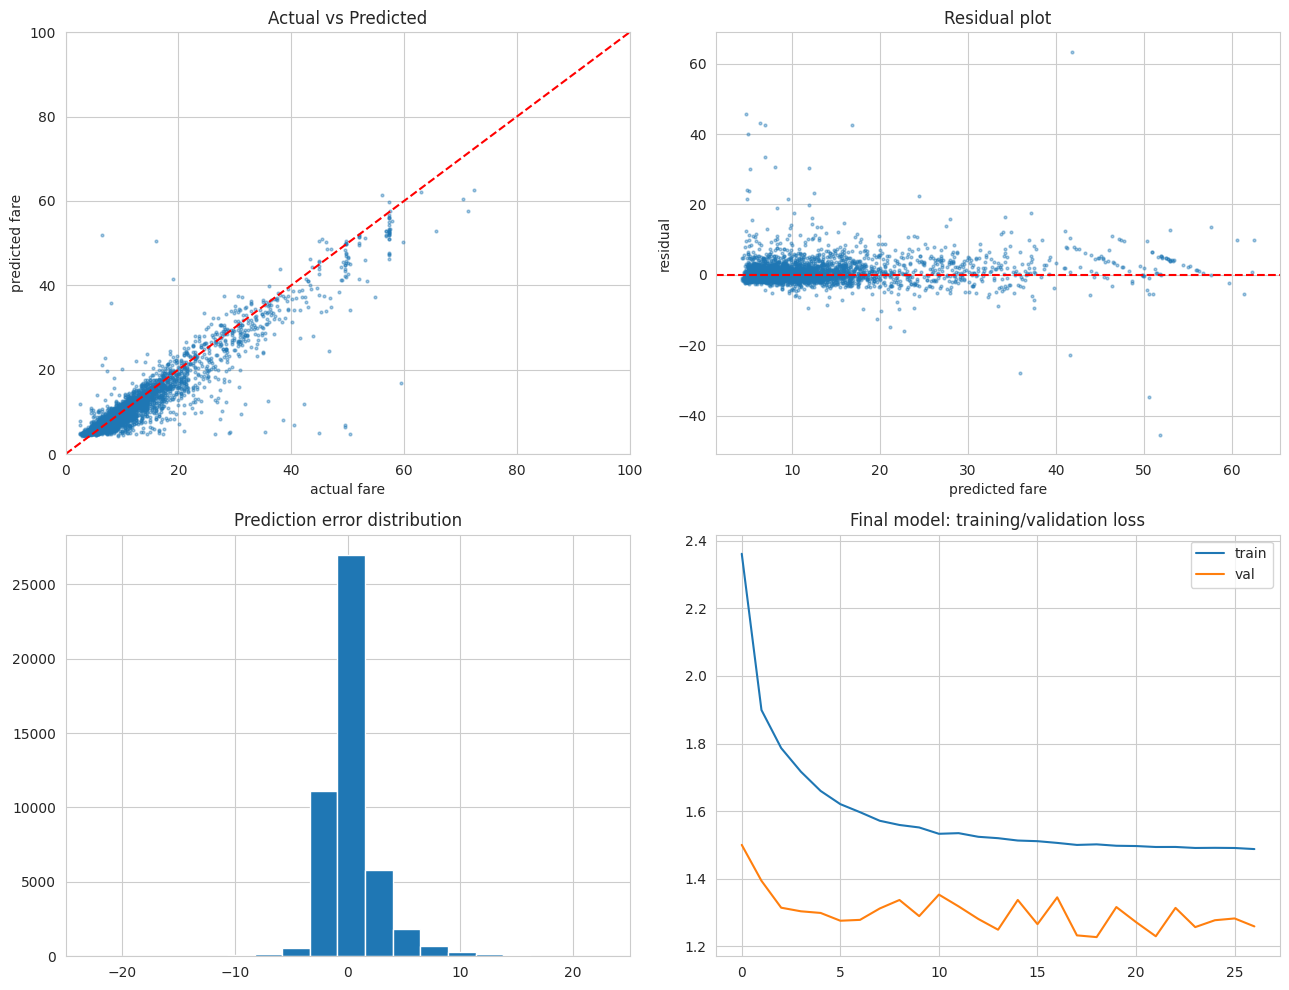

In [17]:
# 16. MODEL EVALUATION (test set)
y_pred = final_model.predict(X_test_sc).ravel()
final_report = report('Final Tuned DNN', y_test, y_pred)
print(final_report)
print(pd.DataFrame(results + [final_report]))

resid = y_test.values - y_pred
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
lim = [0, 100]
idx = np.random.RandomState(RANDOM_SEED).choice(len(y_test), min(5000, len(y_test)), replace=False)
axes[0,0].scatter(y_test.values[idx], y_pred[idx], s=4, alpha=0.4)
axes[0,0].plot(lim, lim, 'r--'); axes[0,0].set_xlim(lim); axes[0,0].set_ylim(lim)
axes[0,0].set_xlabel('actual fare'); axes[0,0].set_ylabel('predicted fare'); axes[0,0].set_title('Actual vs Predicted')

axes[0,1].scatter(y_pred[idx], resid[idx], s=4, alpha=0.4); axes[0,1].axhline(0, color='r', ls='--')
axes[0,1].set_xlabel('predicted fare'); axes[0,1].set_ylabel('residual'); axes[0,1].set_title('Residual plot')

axes[1,0].hist(resid, bins=100); axes[1,0].set_xlim(-25, 25); axes[1,0].set_title('Prediction error distribution')

axes[1,1].plot(final_history.history['loss'], label='train'); axes[1,1].plot(final_history.history['val_loss'], label='val')
axes[1,1].set_title('Final model: training/validation loss'); axes[1,1].legend()
plt.tight_layout(); plt.show()

In [18]:
# 17. SAVE MODEL
final_model.save('taxi_fare_dnn.keras')
joblib.dump(scaler, 'taxi_scaler.pkl')
print('Saved.')

Saved.
